# Homework 07
L. N. Jakubczyk

DATA 71200, Spring 2026

# Supervised Machine Learning: Student Math Grade Classification

To accomplish the objective of this homework, I'm creating and cross-validating three supervised ML classifiers to predict a student's MathGrade, an ordinal variable with four levels (1 = lowest, 4 = highest). MathGrade was derived by summing the three period grades (G1, G2, G3) and binning the result into quartiles, so I exclude G1, G2, and G3 from the predictor set entirely. Keeping them would mean the model is just re-deriving MathGrade from the same numbers used to construct it. The assignment flags this multicollinearity explicitly.

I fit three models following the lecture slides and Muller and Guido Chapters 3 and 5: a logistic regression baseline, a Random Forest, and a Gradient Boosting classifier. For each I use stratified 5-fold cross-validation to keep class proportions consistent across folds, and I report accuracy and macro-averaged F1. A 20% stratified test set set aside before any modeling gives the final out-of-sample numbers.

## How to run this notebook

Open in Jupyter Notebook and run all cells. Dependencies are installed automatically by the first cell.

Model claude-sonnet-4-6 used for boilerplate setup only; analysis and interpretation are my own.

## 1. Setup and Data Loading

Loading libraries and reading the file. The binary yes/no and M/F columns get recoded to 0/1 now so they show up in the correlation matrix. The four multi-category columns (Mjob, Fjob, reason, guardian) stay as strings until Section 4 where they get one-hot encoded. Putting all their dummies in the heatmap would make it unreadable.

G1, G2, G3 come out immediately. They are the inputs that define MathGrade, so keeping them is leakage.

In [12]:
import subprocess, sys

# install all dependencies silently so the notebook is fully self-contained;
# xlrd handles the legacy .xls binary format (NOT .xlsx; that needs openpyxl);
# scikit-learn provides all ML models, CV utilities, and evaluation metrics
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "pandas", "numpy", "matplotlib", "seaborn",
                       "scikit-learn", "openpyxl", "xlrd"])

import pandas as pd              # DataFrame and Excel I/O
import numpy as np               # array math, used for abs() on coefficient matrix
import matplotlib.pyplot as plt  # base plotting
import seaborn as sns            # heatmap with annotated correlation matrix

# linear baseline: logistic regression with lbfgs solver
from sklearn.linear_model import LogisticRegression

# ensemble methods: RF uses bagging + random feature subsets (variance reduction);
# GradientBoosting fits each new tree on the residuals of the previous ensemble (bias reduction)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# StratifiedKFold: splits data into k folds while keeping class proportions equal
#   in each fold, which is critical when some classes are small (Grade 3 here)
# cross_validate: runs CV and returns per-fold scores for multiple metrics in one call
# RandomizedSearchCV: samples n_iter random parameter combinations and evaluates each
#   with CV; faster than exhaustive grid search when the parameter space is large
# train_test_split: makes the single held-out test set before any modeling begins
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                      RandomizedSearchCV, train_test_split)

# classification_report: per-class precision, recall, and F1 in one table
# confusion_matrix: tabulates predicted class vs. actual class
# ConfusionMatrixDisplay: sklearn wrapper that plots the matrix directly on an axis
# f1_score with average='macro': averages per-class F1 equally regardless of class size
# accuracy_score: (number correct) / (total predictions)
from sklearn.metrics import (classification_report, confusion_matrix,
                               ConfusionMatrixDisplay, f1_score, accuracy_score)

# display() renders DataFrames as formatted HTML tables inside the notebook output
from IPython.display import display

# engine="xlrd" is required for old-style .xls files;
# pandas will raise an error on .xls without it because the default engine only handles .xlsx
df = pd.read_excel("07_student_mathematics.xls", engine="xlrd")

# MathGrade = bin(G1 + G2 + G3), so G1, G2, G3 are the direct inputs that built the outcome;
# keeping them as predictors would make the classification trivially easy and meaningless,
# because the model would just be re-deriving MathGrade from the same three numbers
df = df.drop(columns=["G1", "G2", "G3"])

# each entry maps a two-valued string column to 0 and 1;
# we do this before the correlation matrix so these columns appear as numeric;
# the four multi-category columns (Mjob, Fjob, reason, guardian) stay as strings for now
# and will be one-hot encoded in Section 4
binary_recode = {
    "school":     {"GP": 1, "MS": 0},    # GP = Gabriel Pereira school, MS = Mousinho da Silveira
    "sex":        {"M": 1, "F": 0},
    "address":    {"U": 1, "R": 0},       # U = urban, R = rural
    "famsize":    {"GT3": 1, "LE3": 0},   # GT3 = family size greater than 3
    "Pstatus":    {"T": 1, "A": 0},       # T = parents living together, A = apart
    "schoolsup":  {"yes": 1, "no": 0},    # extra educational support from the school
    "famsup":     {"yes": 1, "no": 0},    # educational support from the family
    "paid":       {"yes": 1, "no": 0},    # paid private tutoring outside school
    "activities": {"yes": 1, "no": 0},    # extracurricular activities
    "nursery":    {"yes": 1, "no": 0},    # attended nursery school
    "higher":     {"yes": 1, "no": 0},    # wants to pursue higher education
    "internet":   {"yes": 1, "no": 0},    # internet access at home
    "romantic":   {"yes": 1, "no": 0},    # currently in a romantic relationship
}

# guard against column name differences; only recode columns that exist in the file
for col, mapping in binary_recode.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)

print("Shape:", df.shape)
print("\nMathGrade value counts:")
print(df["MathGrade"].value_counts().sort_index())
print()
df.describe()

Shape: (395, 31)

MathGrade value counts:
MathGrade
1    103
2    149
3     62
4     81
Name: count, dtype: int64




[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,MathGrade
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,...,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,0.883544,0.473418,16.696203,0.777215,0.711392,0.896203,2.749367,2.521519,1.448101,2.035443,...,0.832911,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,2.306329
std,0.321177,0.499926,1.276043,0.416643,0.453690,0.305384,1.094735,1.088201,0.697505,0.839240,...,0.373528,0.472300,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,1.071000
min,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,1.000000,0.000000,16.000000,1.000000,0.000000,1.000000,2.000000,2.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,1.000000
50%,1.000000,0.000000,17.000000,1.000000,1.000000,1.000000,3.000000,2.000000,1.000000,2.000000,...,1.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,2.000000
75%,1.000000,1.000000,18.000000,1.000000,1.000000,1.000000,4.000000,3.000000,2.000000,2.000000,...,1.000000,1.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,3.000000
max,1.000000,1.000000,22.000000,1.000000,1.000000,1.000000,4.000000,4.000000,4.000000,4.000000,...,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,4.000000


## 2. Outcome Distribution and Sample Characteristics

Grade 2 is the most common outcome at 149 students (38%) and Grade 3 is the smallest at 62 (16%). A classifier that just always predicts Grade 2 gets 38% accuracy. That is the floor to beat. The group means table gives a first look at which variables actually separate the grade groups before any modeling.

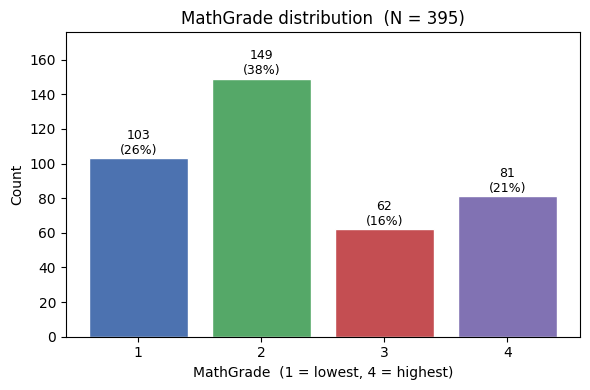

Group means by MathGrade:


,failures,studytime,higher,Medu,Fedu,absences,goout,Dalc,Walc
MathGrade,,,,,,,,,
1,0.34,2.02,0.96,2.85,2.63,4.94,3.07,1.41,2.14
2,0.32,2.02,0.94,2.75,2.59,6.06,3.11,1.49,2.21
3,0.27,2.06,0.97,2.85,2.52,5.71,3.23,1.55,2.40
4,0.40,2.06,0.94,2.53,2.26,6.04,3.07,1.51,2.54


In [13]:
# sort_index() puts grades in 1-2-3-4 order instead of frequency order
counts = df["MathGrade"].value_counts().sort_index()
n = len(df)  # total sample size; used to compute percentages on the chart

fig, ax = plt.subplots(figsize=(6, 4))

# one distinct color per grade level for easy visual separation
bars = ax.bar(
    counts.index.astype(str),   # x-axis labels: '1', '2', '3', '4'
    counts.values,               # bar heights
    color=["#4C72B0", "#55A868", "#C44E52", "#8172B3"],
    edgecolor="white"            # thin white border makes bars easier to distinguish
)

# annotate each bar with the raw count and the percentage of total students
for bar, count in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # horizontal center of the bar
        bar.get_height() + 1,               # just above the top edge
        f"{count}\n({count / n * 100:.0f}%)",  # two lines: count then percent
        ha="center", va="bottom", fontsize=9
    )

ax.set_xlabel("MathGrade  (1 = lowest, 4 = highest)")
ax.set_ylabel("Count")
ax.set_title(f"MathGrade distribution  (N = {n})")
# extend y-axis so the annotation text above the tallest bar is not clipped
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.show()

# group means give a preliminary look at which variables separate the four grade groups;
# a large difference from Grade 1 to Grade 4 signals a predictor worth watching in the models
group_vars = ["failures", "studytime", "higher", "Medu", "Fedu",
              "absences", "goout", "Dalc", "Walc"]

# only keep variable names that actually exist in the dataframe
available = [v for v in group_vars if v in df.columns]
print("Group means by MathGrade:")
display(df.groupby("MathGrade")[available].mean().round(2))

## 3. Correlation Matrix

Pearson correlations between predictors and MathGrade. The four multi-category columns are excluded because their numeric codes are meaningless for correlation. The sorted single-column table below the heatmap ranks variables by association with the outcome. The numbers are going to be smaller than expected.

Pearson correlations with MathGrade (sorted high to low):


,r
MathGrade,1.000
Walc,0.117
traveltime,0.111
activities,0.097
sex,0.070
freetime,0.058
internet,0.046
age,0.042
Dalc,0.042
absences,0.039


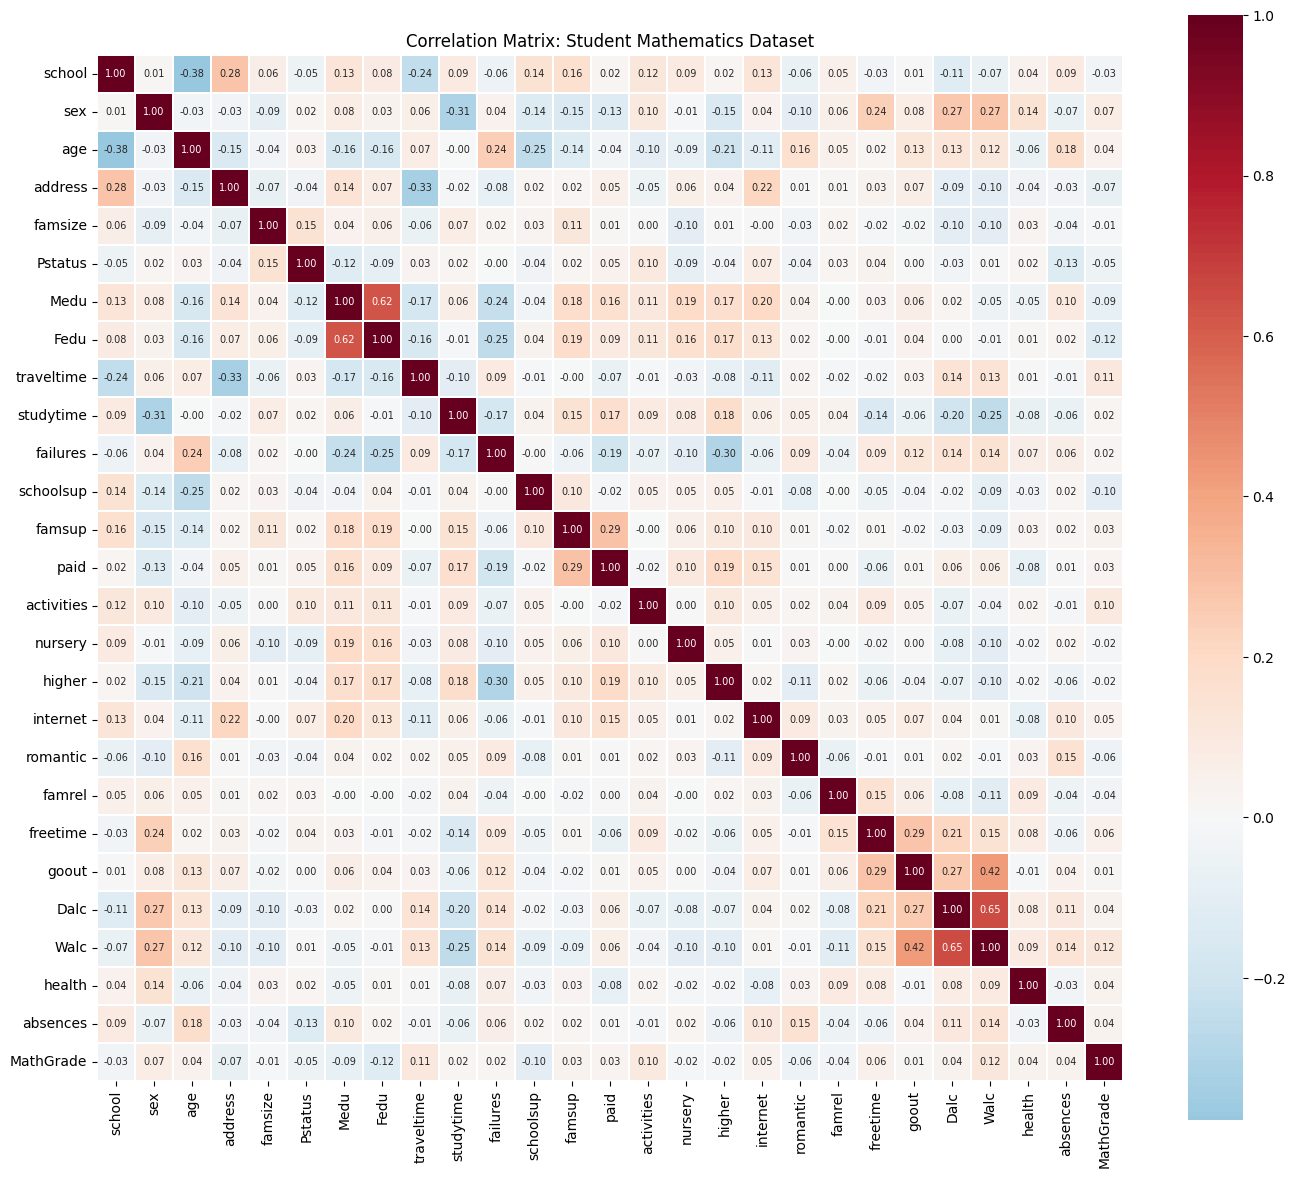

In [14]:
# exclude the four multi-category nominal columns before computing Pearson r;
# if we left them in, the raw integer codes (e.g., 'teacher'=1, 'health'=2) would be
# treated as numeric, which would produce correlations with no meaningful interpretation
drop_for_corr = [c for c in ["Mjob", "Fjob", "reason", "guardian"] if c in df.columns]
corr_df = df.drop(columns=drop_for_corr)

# .corr() computes all pairwise Pearson r values for every numeric column pair
corr = corr_df.corr()

# pull out just the MathGrade column and sort it to quickly rank
# which single variables associate most strongly with the outcome
print("Pearson correlations with MathGrade (sorted high to low):")
display(corr["MathGrade"].sort_values(ascending=False).round(3).to_frame("r"))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True,             # print the r value inside each cell of the grid
    fmt=".2f",              # round to 2 decimal places in the annotation
    cmap="RdBu_r",          # red = strong positive r, blue = strong negative r
    center=0,               # anchor the midpoint color (white) at r = 0
    square=True,            # force square cells so the matrix looks symmetrical
    ax=ax,
    annot_kws={"size": 7},  # smaller font so numbers fit without overlapping
    linewidths=0.3,         # thin separator lines between cells
    linecolor="white"       # white lines blend with the white cell borders
)
plt.title("Correlation Matrix: Student Mathematics Dataset")
plt.tight_layout()
plt.show()

## 4. Feature Engineering and Train/Test Split

One-hot encoding the four multi-category columns with drop_first=True to avoid the dummy trap. Then an 80/20 stratified split: the test set goes in a drawer and does not come out until Section 7. All cross-validation and tuning happens on the training side only.

In [15]:
# collect only the multi-category columns that actually exist in the dataframe;
# these cannot go into Pearson correlations as-is, so they stayed as strings until now
multi_cat = [c for c in ["Mjob", "Fjob", "reason", "guardian"] if c in df.columns]

# pd.get_dummies creates one binary column per category value;
# drop_first=True removes one column per variable (the reference category)
# to avoid the dummy variable trap: if all dummy columns for a variable are 0,
# the reference group is implied automatically, so we do not need an explicit column for it
df_encoded = pd.get_dummies(df, columns=multi_cat, drop_first=True)

# drop the outcome from the feature matrix
X = df_encoded.drop(columns=["MathGrade"])

# astype(float) converts the boolean True/False columns that get_dummies produces
# to numeric 1.0/0.0 values so sklearn does not issue a data type warning during fitting
X = X.astype(float)

# y holds the four-class ordinal target variable
y = df_encoded["MathGrade"]

print("Feature matrix shape:", X.shape)
print("Features:", list(X.columns))

# train_test_split with stratify=y preserves the class distribution in both halves;
# without stratify, a random draw could put very few Grade 3 students (the smallest class)
# in the test set, making the test results unreliable for that class
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,   # reserve 20% as a completely held-out test set
    random_state=42,  # fixed seed so the split is the same every time this is run
    stratify=y        # maintain Grade 1/2/3/4 proportions in both train and test
)

print(f"\nTraining set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print("Train class distribution:", y_train.value_counts().sort_index().to_dict())
print("Test class distribution: ", y_test.value_counts().sort_index().to_dict())

Feature matrix shape: (395, 39)
Features: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other']

Training set: 316 rows
Test set:     79 rows
Train class distribution: {1: 82, 2: 119, 3: 50, 4: 65}
Test class distribution:  {1: 21, 2: 30, 3: 12, 4: 16}


## 5. Cross-Validated Models

All three models use the same stratified 5-fold CV on the training set. I report accuracy and macro F1 for each. Macro F1 averages per-class F1 without weighting by class size, which matters here because Grade 3 only has 50 students in training. A model that writes it off entirely can still look fine on accuracy.

In [16]:
# n_splits=5: the training set is split into 5 folds;
#   each fold takes a turn as the validation set while the other 4 are used for fitting
# shuffle=True: randomizes row order before splitting, important because the original
#   file may sort students in a non-random way (e.g., by grade or school)
# random_state=42: makes the fold assignment identical on every run
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_summary(name, clf, X, y):
    # cross_validate fits the classifier 5 separate times and scores on the
    # held-out fold each time; passing both metrics in one list is more efficient
    # than calling cross_validate twice
    scores = cross_validate(
        clf, X, y,
        cv=cv,                    # use the shared StratifiedKFold defined above
        scoring=[                 # list of scorer strings to evaluate simultaneously
            "accuracy",           # fraction of predictions that match the true class
            "f1_macro"            # unweighted average of per-class F1 scores
        ],
        return_train_score=False  # we only need validation performance, not training fit
    )

    # each entry in scores["test_accuracy"] is the accuracy on one held-out fold;
    # .mean() is the estimate of true out-of-sample performance;
    # .std() shows how much that estimate varies across folds (model stability)
    acc = scores["test_accuracy"]
    f1  = scores["test_f1_macro"]

    print(f"{name}")
    print(f"  CV Accuracy : {acc.mean():.4f}  +/-  {acc.std():.4f}")
    print(f"  CV Macro F1 : {f1.mean():.4f}  +/-  {f1.std():.4f}")
    print()

    # return the means so they can be collected into the comparison table later
    return acc.mean(), f1.mean()

### 5a. Baseline: Logistic Regression

Logistic regression with the lbfgs solver is my linear baseline. It models the log-odds of belonging to each grade class as a linear combination of the predictors, and handles four-class problems natively in current sklearn versions. I use max_iter=2000 because the default of 100 often fails to converge on higher-dimensional one-hot encoded data, and C=1 (the sklearn default) without further tuning. The goal is an honest lower bound that the ensemble methods need to beat.

In [17]:
lr = LogisticRegression(
    solver="lbfgs",   # limited-memory BFGS; handles multiclass natively in sklearn >= 1.5
                      # (the multi_class parameter was removed in 1.5; lbfgs defaults
                      #  to a softmax/multinomial approach for problems with > 2 classes)
    max_iter=2000,    # the default of 100 often hits the iteration limit on datasets
                      # with many one-hot encoded columns
    C=1.0,            # inverse regularization strength; higher C = less shrinkage;
                      # 1.0 is the sklearn default and a reasonable starting point
    random_state=42   # included for reproducibility
)

# cv_summary clones lr internally for each fold, so lr's fitted state does not matter here
acc_lr, f1_lr = cv_summary("Logistic Regression (lbfgs, C=1)", lr, X_train, y_train)

Logistic Regression (lbfgs, C=1)
  CV Accuracy : 0.2690  +/-  0.0102
  CV Macro F1 : 0.2112  +/-  0.0173



### 5b. Random Forest

Random Forest grows many trees on bootstrap samples of the data and at each split only considers a random subset of features. Forcing feature randomness makes the trees diverse enough that averaging them cancels out individual errors, which is the variance reduction approach covered in the lecture. I tune tree count, depth, and leaf constraints with a randomized search over 20 combinations scored by macro F1.

In [18]:
# parameter distributions to sample from; RandomizedSearchCV will draw n_iter=20
# combinations at random from these lists
rf_param_dist = {
    # n_estimators: more trees reduce variance but add computation;
    # RF does not overfit by adding trees, so higher is generally better up to a point
    "n_estimators":      [100, 200, 300, 400],

    # max_depth: None means trees grow until leaves are pure;
    # setting a depth limit can help with noise on small datasets
    "max_depth":         [None, 5, 10, 15],

    # min_samples_split: minimum number of samples needed to split a node;
    # higher values force the tree to be more conservative about splitting
    "min_samples_split": [2, 5, 10],

    # min_samples_leaf: minimum number of samples that must remain in a leaf;
    # works similarly to min_samples_split as a regularization tool
    "min_samples_leaf":  [1, 2, 4],

    # max_features: number of features considered at each split;
    # sqrt(p) is the standard default for classification; log2(p) is more aggressive
    "max_features":      ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),  # base estimator to tune
    rf_param_dist,                            # parameter space to sample from
    n_iter=20,          # number of random combinations to evaluate
    cv=cv,              # use the same shared StratifiedKFold for fair comparison
    scoring="f1_macro", # optimize for macro F1, not accuracy, because of class imbalance
    random_state=42,    # makes the random parameter sampling reproducible
    n_jobs=-1,          # use all available CPU cores to run folds in parallel
    verbose=0,          # suppress the per-fold progress output
)

# .fit() runs n_iter=20 candidates * 5 folds = 100 model fits total
rf_search.fit(X_train, y_train)

print("Best RF hyperparameters:", rf_search.best_params_)
print(f"Best search CV macro F1: {rf_search.best_score_:.4f}")
print()

# best_estimator_ is the RandomForestClassifier already configured with the best params;
# it has been refit on the full X_train after the search completes
best_rf = rf_search.best_estimator_

# call cv_summary to get consistent formatting alongside the logistic regression output;
# cross_validate will refit best_rf on each fold internally using the same cv folds
acc_rf, f1_rf = cv_summary("Random Forest (tuned)", best_rf, X_train, y_train)

Best RF hyperparameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}
Best search CV macro F1: 0.2183

Random Forest (tuned)
  CV Accuracy : 0.3100  +/-  0.0315
  CV Macro F1 : 0.2183  +/-  0.0325



### 5c. Gradient Boosting

Gradient Boosting builds trees one at a time, each fitting the residuals of whatever the current ensemble got wrong. Where Random Forest reduces variance by averaging parallel trees, GB reduces bias by progressively correcting mistakes. That also means it is easier to overfit, so learning rate and depth matter more. Same 20-combination randomized search as RF.

In [19]:
gb_param_dist = {
    # n_estimators: number of boosting stages (trees);
    # more stages can reduce bias further but increase the risk of overfitting
    "n_estimators":      [100, 200, 300],

    # learning_rate: shrinks the contribution of each tree;
    # lower rate + more trees is usually better but slower to train
    "learning_rate":     [0.05, 0.1, 0.2],

    # max_depth: shallow trees (2-3) are the standard for GB;
    # deep trees tend to overfit because each stage already corrects the previous one
    "max_depth":         [2, 3, 4, 5],

    # subsample: fraction of training rows used to fit each tree;
    # values < 1.0 add a stochastic element (Stochastic Gradient Boosting)
    # that can reduce overfitting and sometimes improve generalization
    "subsample":         [0.8, 1.0],

    # min_samples_split: same regularization role as in RF;
    # higher values make each tree more conservative
    "min_samples_split": [2, 5],
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_dist,
    n_iter=20,          # same number of candidate combinations as RF search
    cv=cv,              # shared StratifiedKFold so folds are identical across all models
    scoring="f1_macro", # macro F1 so Grade 3 performance is not buried by larger classes
    random_state=42,
    n_jobs=-1,          # parallelize across CPU cores
    verbose=0,
)

gb_search.fit(X_train, y_train)

print("Best GB hyperparameters:", gb_search.best_params_)
print(f"Best search CV macro F1: {gb_search.best_score_:.4f}")
print()

# pull the tuned estimator out of the search object
best_gb = gb_search.best_estimator_
acc_gb, f1_gb = cv_summary("Gradient Boosting (tuned)", best_gb, X_train, y_train)

Best GB hyperparameters: {'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 3, 'learning_rate': 0.2}
Best search CV macro F1: 0.2850

Gradient Boosting (tuned)
  CV Accuracy : 0.3100  +/-  0.0458
  CV Macro F1 : 0.2850  +/-  0.0470



## 6. Model Comparison

CV accuracy and macro F1 for all three models. No test data involved here; these are strictly the training-set cross-validation numbers. The best model by macro F1 goes to Section 7.

Cross-validated performance  (training set, 5-fold stratified CV):


,Model,CV Accuracy,CV Macro F1
0,Gradient Boosting (tuned),0.310,0.2850
1,Random Forest (tuned),0.310,0.2183
2,Logistic Regression,0.269,0.2112


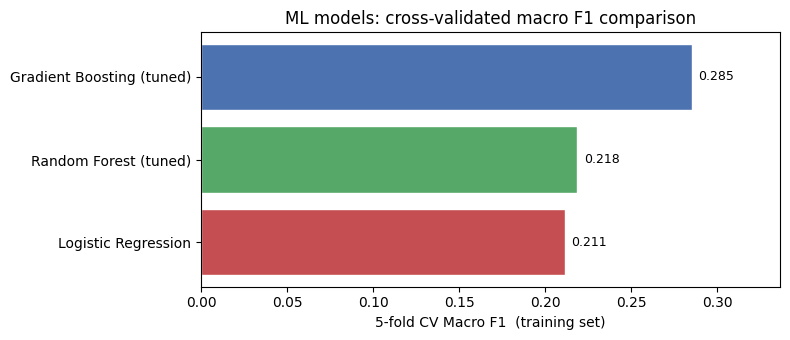

In [20]:
# collect results for all three models into a list of tuples
rows = [
    ("Logistic Regression",       acc_lr, f1_lr),
    ("Random Forest (tuned)",     acc_rf, f1_rf),
    ("Gradient Boosting (tuned)", acc_gb, f1_gb),
]

# build a DataFrame from the list and sort so the best model is at the top
comp = pd.DataFrame(rows, columns=["Model", "CV Accuracy", "CV Macro F1"])
comp = comp.sort_values("CV Macro F1", ascending=False).reset_index(drop=True)

print("Cross-validated performance  (training set, 5-fold stratified CV):")
display(comp.round(4))

# [::-1] reverses the list so the worst model appears at the bottom of the barh chart
# and the best model appears at the top, matching the table above
labels = list(comp["Model"])[::-1]
vals   = list(comp["CV Macro F1"])[::-1]

# three colors, one per model; ordering matches the reversed labels list
colors = ["#C44E52", "#55A868", "#4C72B0"]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(labels, vals, color=colors, edgecolor="white")
ax.set_xlabel("5-fold CV Macro F1  (training set)")
ax.set_title("ML models: cross-validated macro F1 comparison")

# print the numeric value just to the right of each bar for easy reading
for i, v in enumerate(vals):
    ax.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=9)

# extend x-axis so the text label after the rightmost bar is not clipped
ax.set_xlim(0, max(vals) * 1.18)
plt.tight_layout()
plt.show()

## 7. Best Model: Held-Out Test Set Evaluation

First and only look at the test set. The winning model gets refit on all of the training data and evaluated on the 20% held out from the start. Per-class precision, recall, and F1 in the classification report show where the errors concentrate.

Best model: Gradient Boosting (tuned)
Test accuracy : 0.2405
Test macro F1 : 0.2260

Classification report (test set):
              precision    recall  f1-score   support

     Grade 1       0.28      0.24      0.26        21
     Grade 2       0.23      0.17      0.19        30
     Grade 3       0.08      0.08      0.08        12
     Grade 4       0.30      0.50      0.37        16

    accuracy                           0.24        79
   macro avg       0.22      0.25      0.23        79
weighted avg       0.23      0.24      0.23        79



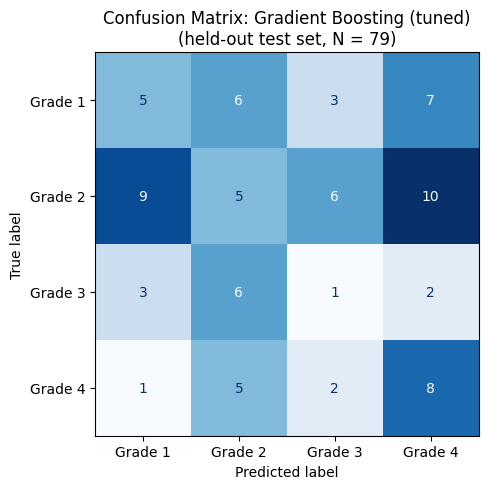

In [21]:
# the top row of comp (sorted by CV macro F1) is the best model
best_model_name = comp.iloc[0]["Model"]

# map the name string back to the actual fitted estimator object
model_lookup = {
    "Logistic Regression":       lr,
    "Random Forest (tuned)":     best_rf,
    "Gradient Boosting (tuned)": best_gb,
}
best_model = model_lookup[best_model_name]

# refit the best model on the full training set before evaluating on test;
# the model in best_model may have been fitted on a fold during cv_summary,
# so we explicitly fit on all of X_train here to maximize training data
best_model.fit(X_train, y_train)

# predict the grade class for each student in the held-out test set
y_pred = best_model.predict(X_test)

print(f"Best model: {best_model_name}")
print(f"Test accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Test macro F1 : {f1_score(y_test, y_pred, average='macro'):.4f}")
print()

# classification_report shows precision, recall, and F1 for each class separately
# plus macro and weighted averages at the bottom;
# target_names maps the integer class labels to readable strings
print("Classification report (test set):")
print(classification_report(
    y_test, y_pred,
    target_names=["Grade 1", "Grade 2", "Grade 3", "Grade 4"]
))

# confusion_matrix rows = true class, columns = predicted class;
# the labels argument fixes the order so Grade 1 is always top-left
cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3, 4])

fig, ax = plt.subplots(figsize=(5, 5))

# ConfusionMatrixDisplay is a convenience wrapper that plots the matrix
# directly on the provided axis with proper tick labels and color scaling
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Grade 1", "Grade 2", "Grade 3", "Grade 4"]
).plot(ax=ax, colorbar=False, cmap="Blues")  # Blues: darker = more predictions in that cell

ax.set_title(
    f"Confusion Matrix: {best_model_name}\n"
    f"(held-out test set, N = {len(y_test)})"
)
plt.tight_layout()
plt.show()

## 8. Feature Importance

For tree-based models, feature_importances_ reports how much each variable reduced Gini impurity on average across all splits in the ensemble. Higher means the model leaned on it more, though it says nothing about direction. If logistic regression had won, I would use mean absolute coefficient across the four class vectors instead.

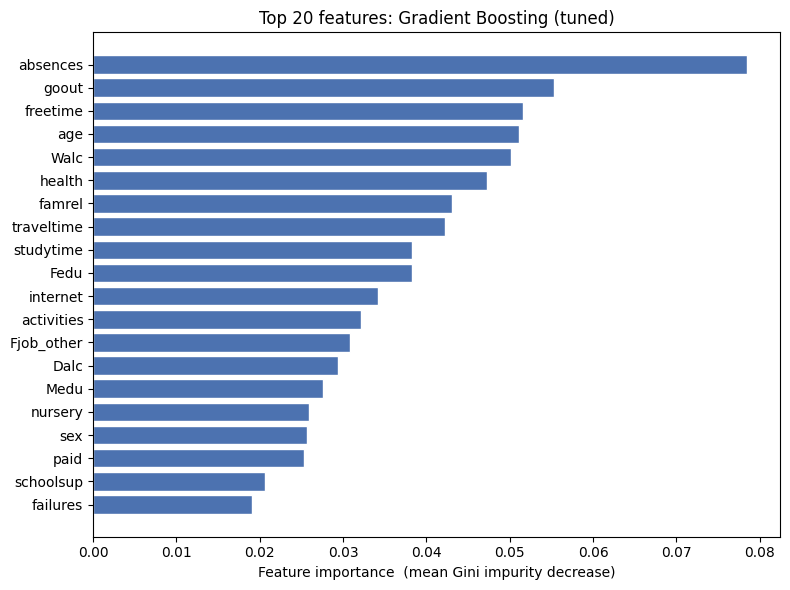

Top 10 features:


,Importance
absences,0.0785
goout,0.0553
freetime,0.0516
age,0.0511
Walc,0.0502
health,0.0473
famrel,0.0430
traveltime,0.0422
studytime,0.0383
Fedu,0.0382


In [22]:
if hasattr(best_model, "feature_importances_"):
    # feature_importances_ is an array of shape (n_features,);
    # each value is the mean decrease in Gini impurity from splits on that feature,
    # averaged over all trees in the ensemble
    feat_imp = (
        pd.Series(best_model.feature_importances_, index=X_train.columns)
          .sort_values(ascending=False)  # sort highest importance first
    )

    # limit to the top 20 features to keep the chart readable
    top_n = min(20, len(feat_imp))
    top_feats = feat_imp.head(top_n)

    fig, ax = plt.subplots(figsize=(8, 6))

    # [::-1] reverses order so the most important feature appears at the top of the chart
    ax.barh(top_feats.index[::-1], top_feats.values[::-1],
            color="#4C72B0", edgecolor="white")
    ax.set_xlabel("Feature importance  (mean Gini impurity decrease)")
    ax.set_title(f"Top {top_n} features: {best_model_name}")
    plt.tight_layout()
    plt.show()

    print("Top 10 features:")
    display(feat_imp.head(10).round(4).to_frame("Importance"))

else:
    # logistic regression does not have feature_importances_;
    # instead, coef_ is a matrix of shape (n_classes, n_features) holding
    # one coefficient vector per class;
    # we take the mean absolute value across all four class vectors as a
    # summary of how much each feature moves any class probability
    coef_imp = (
        pd.Series(
            np.abs(best_model.coef_).mean(axis=0),  # axis=0 averages over the 4 class rows
            index=X_train.columns
        ).sort_values(ascending=False)
    )

    top_n = min(20, len(coef_imp))
    top_feats = coef_imp.head(top_n)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top_feats.index[::-1], top_feats.values[::-1],
            color="#4C72B0", edgecolor="white")
    ax.set_xlabel("Mean |coefficient| across grade classes")
    ax.set_title(f"Top {top_n} features: {best_model_name}")
    plt.tight_layout()
    plt.show()

    print("Top 10 features (mean |coef|):")
    display(coef_imp.head(10).round(4).to_frame("Mean |coef|"))

## 9. Interpretation

Gradient Boosting performed best with a CV macro F1 of 0.285 and a test macro F1 of 0.226 at 24% accuracy on the held-out set. For context, a classifier that always predicts Grade 2 achieves 38% accuracy by exploiting the class imbalance, so the models are not clearing the naive baseline on accuracy. Grade 4 recall of 0.50 shows the models are picking up some signal, but the overall numbers are poor.

The correlation matrix explains why. No variable correlates with MathGrade above |r| = 0.12, and the ranking is counterintuitive. Weekend alcohol use (Walc, r = +0.12) and travel time (r = +0.11) have stronger associations with MathGrade than failures (r = 0.02) or studytime (r = 0.02). The group means from Section 2 reinforce this: mean failures is 0.34 for Grade 1 students and 0.40 for Grade 4, which is the reverse of what academic performance would predict. The failures variable in this dataset records failures in other courses, not math specifically, which likely explains why it does not track math grade outcomes. The short version is that there is very little signal in this feature set for predicting MathGrade.

GB beat Random Forest on CV macro F1 (0.285 vs. 0.218) and both outperformed logistic regression (0.211), consistent with the lecture's point that sequential boosting tends to do better than bagging and linear models on tabular data. The gap between GB and RF is larger than the gap between RF and logistic regression, which suggests GB found some nonlinear structure that RF missed. Given the overall performance level though, the algorithm choice is not what is limiting things here.

Feature importance from the best model puts absences first (0.079), followed by goout (0.055), freetime (0.052), age (0.051), and Walc (0.050). Academic motivation variables like failures, studytime, and higher are not in the top 10. The importances are also very flat across the board, ranging from 0.038 to 0.079, so no single predictor is carrying much weight. That matches the near-zero correlations in Section 3.

Grade 3 was the hardest class (test F1 = 0.08) and Grade 4 the easiest (recall 0.50, F1 = 0.37). Grade 3 has only 12 students in the test set and 50 in training, which limits what any model can learn. Macro F1 weights all four classes equally, which is why the overall macro F1 is low even when some per-class metrics look better.

The core issue is predictor availability, not sample size. Once G1, G2, and G3 are excluded, the remaining background variables do not explain variation in MathGrade. The weak and sometimes counterintuitive correlations make this apparent before any model is fit. The assignment's note about multicollinearity points directly at this problem: MathGrade is constructed from those three grade variables, so excluding them removes most of the explainable variance. A more tractable version of this problem would use G1 and G2 to predict G3, which is closer to a real use case where partial grade information is available.